### Day 19: 一些数据可视化

Bonjour Sarah! 今天让我们运用之前学的知识到实际的生活中。以下情景是Ken突然想到的

今天早上 Ken 迷迷糊糊醒来，发现 eeg 信号很奇怪，大范围（几伏）抖动，用手摸了一下线，似乎又好了。他怀疑线有问题，但是似乎也复刻不出来原先的大范围抖动了。为了让接下来的人（ Sarah 和 Sipeng ）不再出现这个问题，也为了确保昨晚的数据是正常的，Ken决定用python来可视化一下。

Ken 把保存好的 gyroscope 和 channel 6 的 eeg 数据放在了这个文件夹里。接下来由Sarah自由发挥，看看Sarah能不能测算出：

 - Ken 的 eeg 信号在什么时间内抖动？昨晚的数据是否大部分都不可用？
 - 根据 gyroscope 的数据，Ken什么时候在睡觉？

听起来挺有意思的，让我们开始吧哈哈哈。我会先自己写一遍作为参考答案，然后把我的代码扣掉，交给Sarah做练习

In [ ]:
# 首先计算一下数据会不会让内存爆掉
# eeg 数据 1KHz，八小时计算的话，假设使用float64，那么需要 8(h) * 60(min/h) * 60(s/min) * 1000(sample/s) * 8(byte/sample) = 230400000 byte = 230.4 MB
# gyroscope 的数据只有 100Hz，那就更存得下了！

In [ ]:
# plot 第一个 gyro x 数据（gyro应该是角速度吧，不动的情况下应该是0）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"20250706_10\Nora Intan RHD ICM.gyro_x\0001.csv"

# 时间轴是第一列，数据是第二列
# 但是这个csv文件格式不规范，没写header。
df = pd.read_csv(file_path, header=None, names=['time', 'gyro_x'])


print(df.head())

plt.plot(df['time'], df['gyro_x'])
plt.show()

In [ ]:
# plot 第 30 个 gyro x 数据（因为这个是在睡眠中期，假定 Ken 在睡觉，所以数值应该会更小）

file_path = r"20250706_10\Nora Intan RHD ICM.gyro_x\0030.csv"

df = pd.read_csv(file_path, header=None, names=['time', 'gyro_x'])

plt.plot(df['time'], df['gyro_x'])
plt.show()

In [ ]:
# 在这个 cell 里，我们把所有 gyro x 的数据都读取出来，然后画一个图

df_list = []

for index in range(1, 62):
    file_path = rf"20250706_10\Nora Intan RHD ICM.gyro_x\{index:04d}.csv"

    df = pd.read_csv(file_path, header=None, names=['time', 'gyro_x'])
    df_list.append(df)

# 把所有 df 合并成一个
df_all = pd.concat(df_list)

# 画图
plt.plot(df_all['time'], df_all['gyro_x'])
plt.show()

In [ ]:
# 为判断 Ken 是否在睡觉，我们把所有 gyro x, gyro y, gyro z 的数据都读取出来，然后将它们加起来，
# 然后画一个图

df_list = []

for index in range(1, 62):
    gyro_x_file_path = rf"20250706_10\Nora Intan RHD ICM.gyro_x\{index:04d}.csv"
    gyro_y_file_path = rf"20250706_10\Nora Intan RHD ICM.gyro_y\{index:04d}.csv"
    gyro_z_file_path = rf"20250706_10\Nora Intan RHD ICM.gyro_z\{index:04d}.csv"

    gyro_x_df = pd.read_csv(gyro_x_file_path, header=None, names=['time', 'gyro_x'])
    gyro_y_df = pd.read_csv(gyro_y_file_path, header=None, names=['time', 'gyro_y'])
    gyro_z_df = pd.read_csv(gyro_z_file_path, header=None, names=['time', 'gyro_z'])

    df = pd.concat([gyro_x_df['time'], gyro_x_df['gyro_x'], gyro_y_df['gyro_y'], gyro_z_df['gyro_z']], axis=1)
    df_list.append(df)

df_all = pd.concat(df_list)

plt.plot(df_all['time'], df_all['gyro_x'] + df_all['gyro_y'] + df_all['gyro_z'])
plt.show()


Ken 的吐槽：不是，这么乱的吗？我明明在睡觉啊，为什么数据这么乱？

改变一下计划吧，读 acc 数据。在不动的情况下 acc 数据是 1g 的加速度

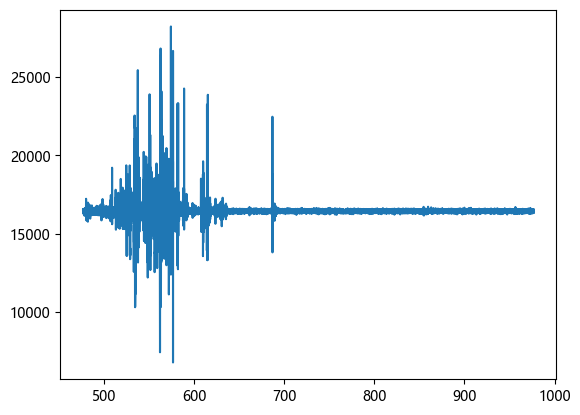

In [35]:
# 读取第一个文件，并将 acc_x, acc_y, acc_z 合成一个向量，并将其 plot 出来

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

acc_x_path = r"20250706_10\Nora Intan RHD ICM.acc_x\0001.csv"
acc_y_path = r"20250706_10\Nora Intan RHD ICM.acc_y\0001.csv"
acc_z_path = r"20250706_10\Nora Intan RHD ICM.acc_z\0001.csv"

df_x = pd.read_csv(acc_x_path, header=None, names=['time', 'acc_x'])
df_y = pd.read_csv(acc_y_path, header=None, names=['time', 'acc_y'])
df_z = pd.read_csv(acc_z_path, header=None, names=['time', 'acc_z'])
# df = pd.concat([df_x, df_y, df_z], axis=1)
df = df_x.merge(df_y, on='time', how='inner').merge(df_z, on='time', how='inner')

df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

plt.plot(df['time'], df['acc_mag'])
plt.show()


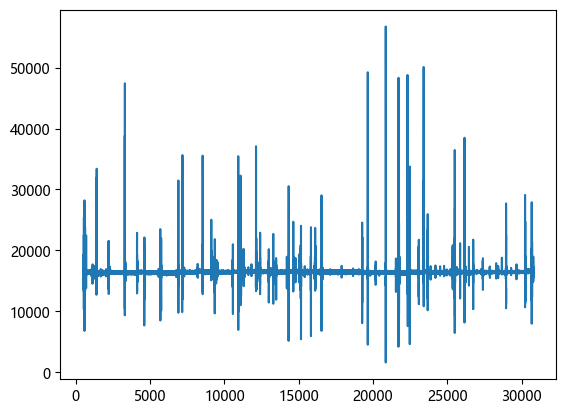

In [44]:
# 读取所有acc文件，并将其合成一个向量，并将其 plot 出来

df_list = []

for index in range(1, 62):
    acc_x_path = rf"20250706_10\Nora Intan RHD ICM.acc_x\{index:04d}.csv"
    acc_y_path = rf"20250706_10\Nora Intan RHD ICM.acc_y\{index:04d}.csv"
    acc_z_path = rf"20250706_10\Nora Intan RHD ICM.acc_z\{index:04d}.csv"

    acc_x_df = pd.read_csv(acc_x_path, header=None, names=['time', 'acc_x'])
    acc_y_df = pd.read_csv(acc_y_path, header=None, names=['time', 'acc_y'])
    acc_z_df = pd.read_csv(acc_z_path, header=None, names=['time', 'acc_z'])

    df = acc_x_df.merge(acc_y_df, on='time', how='inner').merge(acc_z_df, on='time', how='inner')
    df_list.append(df)

df_all = pd.concat(df_list)

df_all['acc_mag'] = np.sqrt(df_all['acc_x']**2 + df_all['acc_y']**2 + df_all['acc_z']**2)

plt.plot(df_all['time'], df_all['acc_mag'])
plt.show()

In [37]:
df_all.tail(100)

,time,acc_x,acc_y,acc_z,acc_mag
35234,30832.67,6608.0,12228.0,-8764.0,16431.595905
35235,30832.68,6548.0,12256.0,-8760.0,16426.303297
35236,30832.69,6600.0,12328.0,-8976.0,16616.502640
35237,30832.70,6604.0,12384.0,-8940.0,16640.308651
35238,30832.71,6644.0,12416.0,-8908.0,16662.900588
...,...,...,...,...,...
35329,30833.62,6292.0,12260.0,-8672.0,16281.905540
35330,30833.63,6332.0,12240.0,-8564.0,16225.101541
35331,30833.64,6344.0,12200.0,-8608.0,16222.946711
35332,30833.65,6400.0,12320.0,-8560.0,16309.996934


In [ ]:
# # 完蛋了，为什么 acc_y 是 NAN

# # 让我单独读一下

# df_y = pd.read_csv(r"20250706_10\Nora Intan RHD ICM.acc_y\0061.csv", header=None, names=['time', 'acc_y'])

# df_y

,time,acc_y
0,30480.33,4488.0
1,30480.34,4640.0
2,30480.35,4560.0
3,30480.36,4552.0
4,30480.37,4556.0
...,...,...
35329,30833.62,12260.0
35330,30833.63,12240.0
35331,30833.64,12200.0
35332,30833.65,12320.0


In [40]:
# 检查 df_all 是否有 NaN 值
print("各列NaN数量：")
print(df_all.isna().sum())
print("\n是否存在NaN：", df_all.isna().any().any())

各列NaN数量：
time       0
acc_x      0
acc_y      0
acc_z      0
acc_mag    0
dtype: int64

是否存在NaN： False


Ken 的吐槽：啊哈哈哈还是很乱。看来我睡觉总是翻身打滚。

哦对了，咱们可以低通滤波。

In [ ]:
# # 截断df_all，只保留前10000个数据点
# df_all = df_all.head(10000)
# df_all


,time,acc_x,acc_y,acc_z,acc_mag
0,477.00,-492.0,13512.0,-9496.0,16522.415804
1,477.01,-576.0,13540.0,-9544.0,16575.624030
2,477.02,-564.0,13456.0,-9460.0,16458.239031
3,477.03,-484.0,13476.0,-9488.0,16488.146530
4,477.04,-636.0,13468.0,-9408.0,16440.863238
...,...,...,...,...,...
9995,576.95,1452.0,-4492.0,15156.0,15874.215067
9996,576.96,1368.0,-4388.0,15052.0,15738.127970
9997,576.97,1632.0,-4516.0,15276.0,16012.927777
9998,576.98,2128.0,-4384.0,15604.0,16347.252246


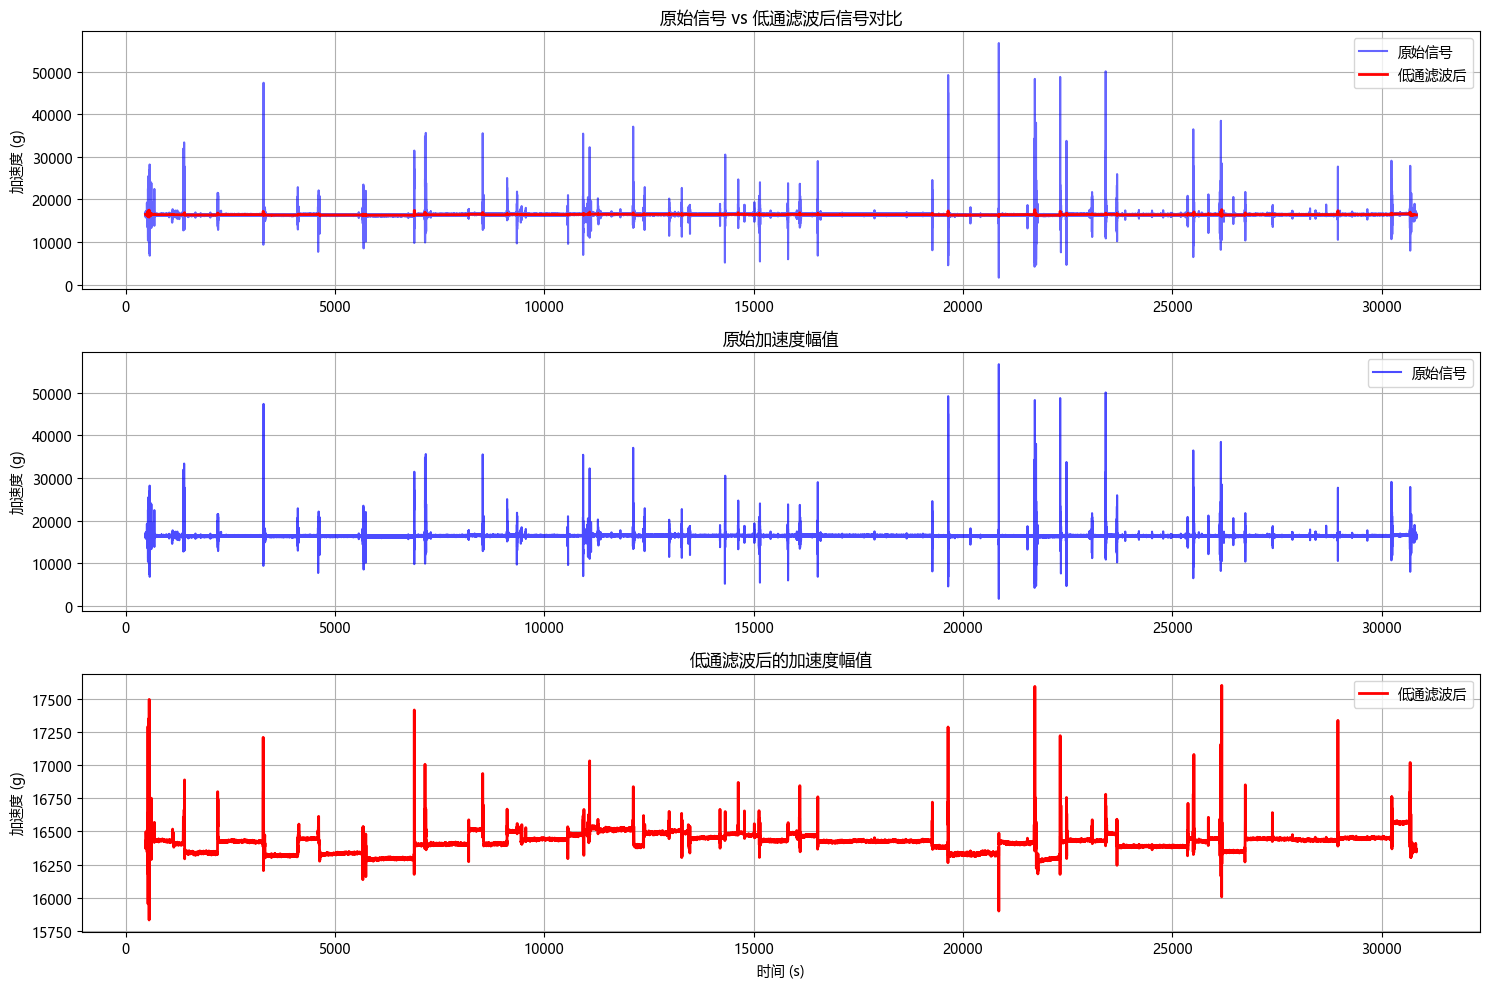

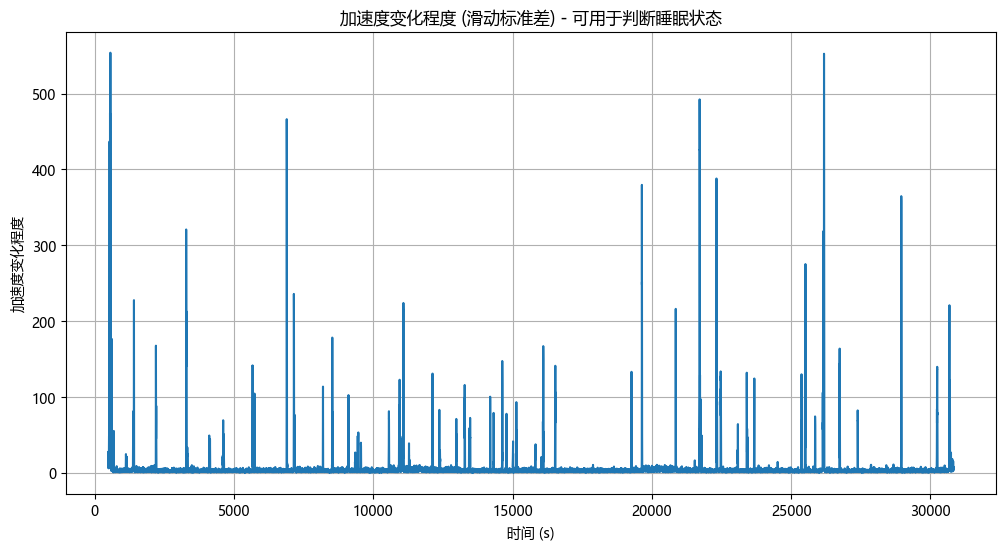

In [46]:
# 对acc_mag数据进行低通滤波，以减少高频噪声
from scipy import signal
import matplotlib

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False


# 假设采样频率为100Hz（根据数据结构推测）
fs = 100  # 采样频率
cutoff = 0.3  # 截止频率0.3Hz，用于去除高频运动噪声

# 设计巴特沃斯低通滤波器
nyquist = fs / 2  # 奈奎斯特频率
normal_cutoff = cutoff / nyquist
b, a = signal.butter(4, normal_cutoff, btype='low', analog=False)

# 应用滤波器
df_all['acc_mag_filtered'] = signal.filtfilt(b, a, df_all['acc_mag'])

# 绘制原始信号和滤波后的信号对比
plt.figure(figsize=(15, 10))

# 第一个子图：两个信号叠加显示
plt.subplot(3, 1, 1)
plt.plot(df_all['time'], df_all['acc_mag'], alpha=0.6, label='原始信号', color='blue')
plt.plot(df_all['time'], df_all['acc_mag_filtered'], label='低通滤波后', color='red', linewidth=2)
plt.title('原始信号 vs 低通滤波后信号对比')
plt.ylabel('加速度 (g)')
plt.legend()
plt.grid(True)

# 第二个子图：只显示原始信号
plt.subplot(3, 1, 2)
plt.plot(df_all['time'], df_all['acc_mag'], alpha=0.7, label='原始信号', color='blue')
plt.title('原始加速度幅值')
plt.ylabel('加速度 (g)')
plt.legend()
plt.grid(True)

# 第三个子图：只显示滤波后信号
plt.subplot(3, 1, 3)
plt.plot(df_all['time'], df_all['acc_mag_filtered'], 'r-', label='低通滤波后', linewidth=2)
plt.title('低通滤波后的加速度幅值')
plt.xlabel('时间 (s)')
plt.ylabel('加速度 (g)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 计算滤波后数据的变化程度来判断运动状态
df_all['acc_variation'] = df_all['acc_mag_filtered'].rolling(window=500, center=True).std()

plt.figure(figsize=(12, 6))
plt.plot(df_all['time'], df_all['acc_variation'])
plt.title('加速度变化程度 (滑动标准差) - 可用于判断睡眠状态')
plt.xlabel('时间 (s)')
plt.ylabel('加速度变化程度')
plt.grid(True)
plt.show()


Ken 再次吐槽：完全看不出来端倪啊怎么回事

哦对，这些数据除了一开始的一点点我应该是全程在睡觉，所以每次一翻身/晃脑袋就会导致加速度有一次变化。如果我是醒着的，加速度变化程度应该会比这个乱很多很多

那让我们看一看eeg的数据有没有异常吧

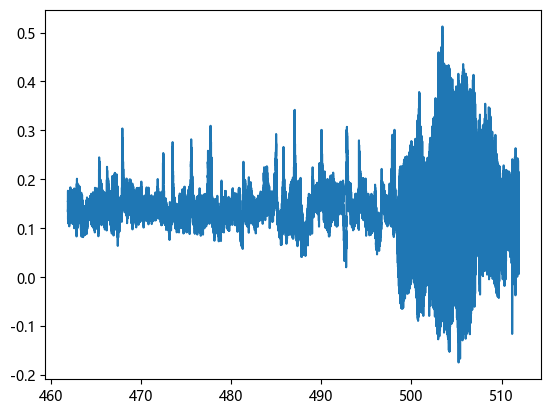

In [7]:
# 查看第一个文件，并将其 plot 出来

import matplotlib
from matplotlib import pyplot as plt
import pandas as pd

matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

file_path = r"20250706_10\Nora Intan RHD ICM.intan_ch6\0001.csv"

df = pd.read_csv(file_path, header=None, names=['time', 'eeg'])

plt.plot(df['time'], df['eeg'])
plt.show()

In [8]:
# 加载所有文件

df_list = []

for index in range(1, 608):
    file_path = rf"20250706_10\Nora Intan RHD ICM.intan_ch6\{index:04d}.csv"

    df = pd.read_csv(file_path, header=None, names=['time', 'eeg'])
    df_list.append(df)

df_all = pd.concat(df_list)
df_all

,time,eeg
0,461.880,0.136110
1,461.881,0.133185
2,461.882,0.135135
3,461.883,0.133965
4,461.884,0.140400
...,...,...
29875,30818.515,0.161070
29876,30818.516,0.161070
29877,30818.517,0.157950
29878,30818.518,0.148590


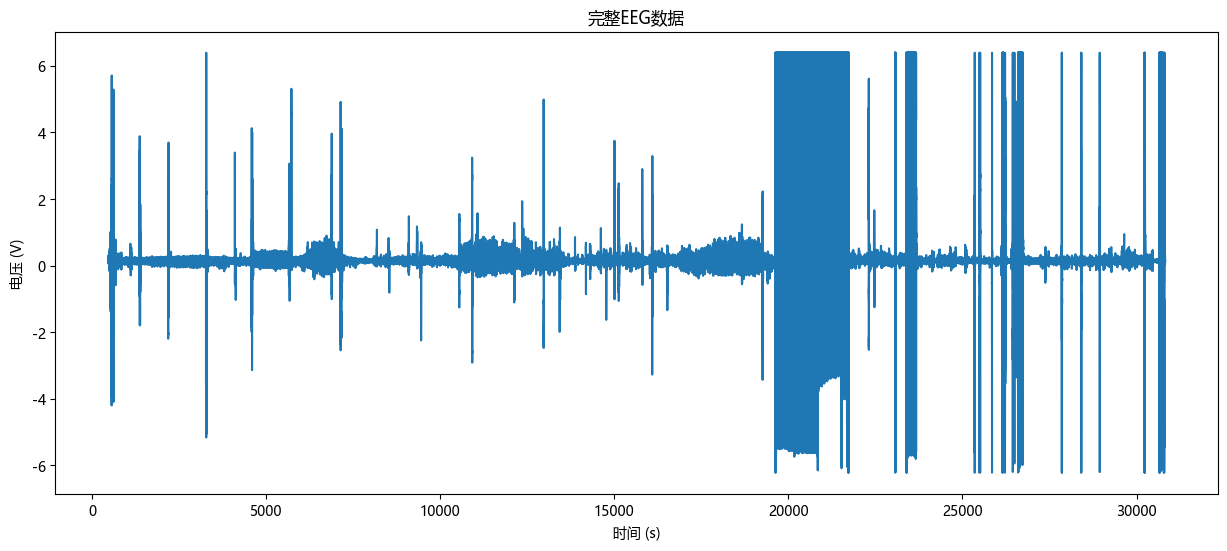

In [9]:
# plot 所有文件
# 设置matplotlib参数来处理大量数据点

matplotlib.rcParams['agg.path.chunksize'] = 10000

plt.figure(figsize=(15, 6))
plt.plot(df_all['time'], df_all['eeg'])
plt.title('完整EEG数据')
plt.xlabel('时间 (s)')
plt.ylabel('电压 (V)')
plt.show()

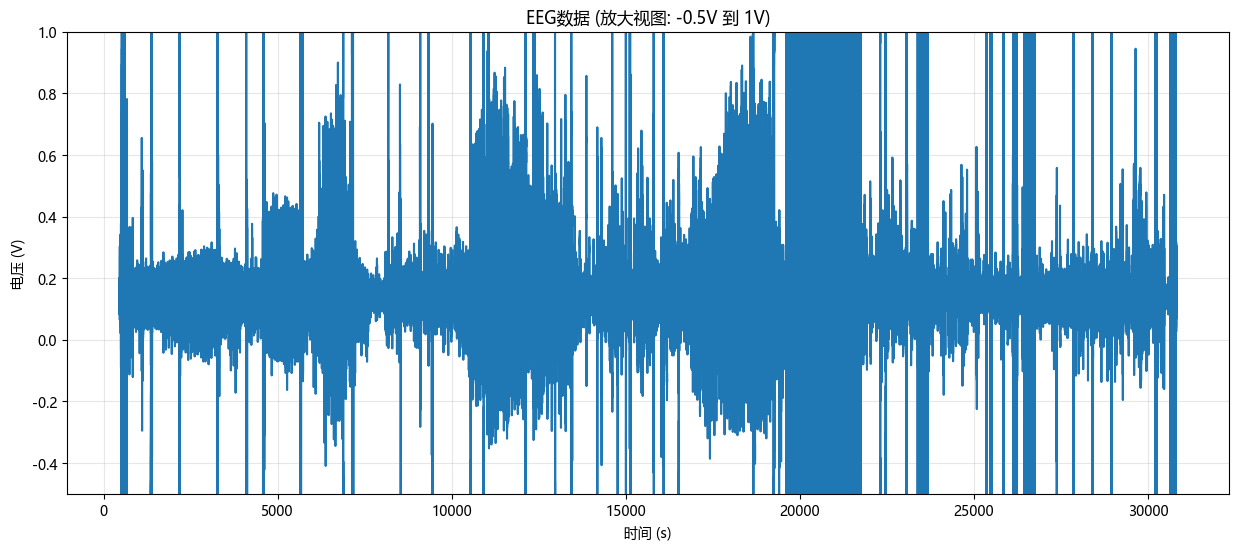

In [10]:
# 只 plot -0.5 - 1 v 的区间
# 确保matplotlib参数已设置
matplotlib.rcParams['agg.path.chunksize'] = 10000

plt.figure(figsize=(15, 6))
plt.plot(df_all['time'], df_all['eeg'])
plt.ylim(-0.5, 1)
plt.title('EEG数据 (放大视图: -0.5V 到 1V)')
plt.xlabel('时间 (s)')
plt.ylabel('电压 (V)')
plt.grid(True, alpha=0.3)
plt.show()

原始数据点数: 30,356,640
采样后数据点数: 3,035,664
数据压缩比例: 10.0%


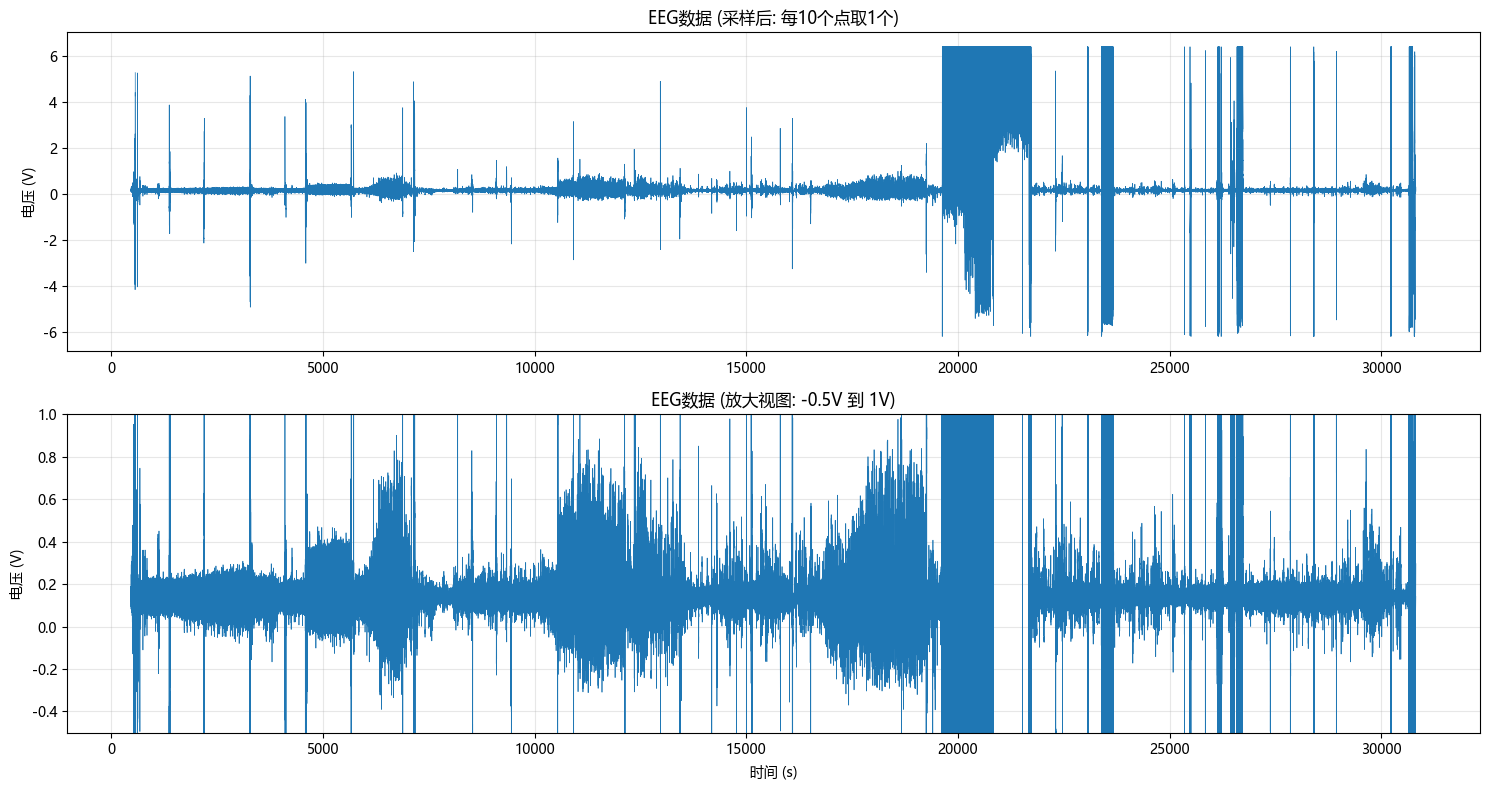

In [11]:
# 方案2：数据采样 - 对于大数据量更高效的可视化方法
# 每隔N个点取一个样本来减少绘图负担

# 计算采样率 - 比如每10个点取1个
sampling_factor = 10
df_sampled = df_all.iloc[::sampling_factor].copy()

print(f"原始数据点数: {len(df_all):,}")
print(f"采样后数据点数: {len(df_sampled):,}")
print(f"数据压缩比例: {len(df_sampled)/len(df_all):.1%}")

# 绘制采样后的数据
plt.figure(figsize=(15, 8))

# 上方：完整范围
plt.subplot(2, 1, 1)
plt.plot(df_sampled['time'], df_sampled['eeg'], linewidth=0.5)
plt.title(f'EEG数据 (采样后: 每{sampling_factor}个点取1个)')
plt.ylabel('电压 (V)')
plt.grid(True, alpha=0.3)

# 下方：放大视图
plt.subplot(2, 1, 2)
plt.plot(df_sampled['time'], df_sampled['eeg'], linewidth=0.5)
plt.ylim(-0.5, 1)
plt.title('EEG数据 (放大视图: -0.5V 到 1V)')
plt.xlabel('时间 (s)')
plt.ylabel('电压 (V)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


EEG信号统计:
均值: 0.5060 V
标准差: 1.5291 V
最大值: 6.3896 V
最小值: -6.2160 V
异常阈值: ±4.5872 V

检测到的异常:
超过阈值的数据点: 188413 个
高变异性数据点: 151734 个
异常时间范围: 561.7s - 30801.0s


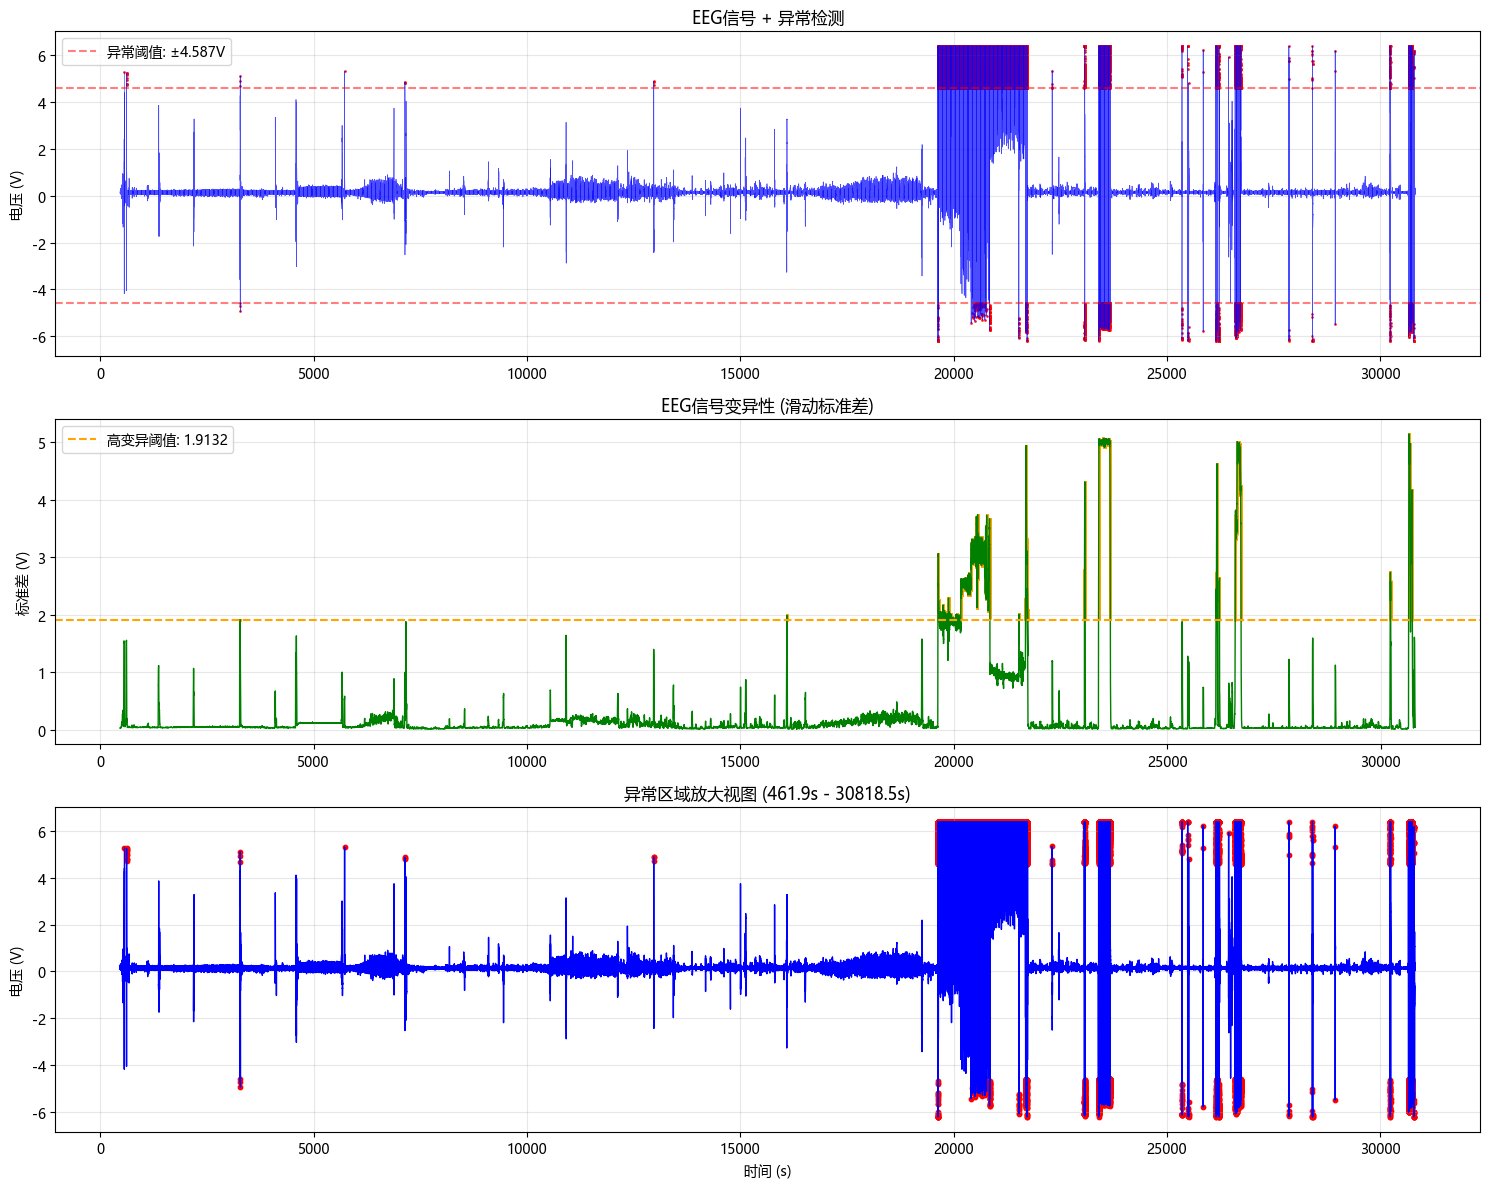

In [12]:
# 分析EEG数据中的异常 - 寻找Ken怀疑的大幅度抖动
# 计算EEG信号的统计特征来识别异常

# 计算滑动窗口的标准差来检测信号的变异性
window_size = 1000  # 窗口大小
df_sampled['eeg_std'] = df_sampled['eeg'].rolling(window=window_size, center=True).std()

# 计算信号的绝对值
df_sampled['eeg_abs'] = df_sampled['eeg'].abs()

# 设置异常检测阈值
eeg_threshold = df_sampled['eeg'].std() * 3  # 3倍标准差作为异常阈值
std_threshold = df_sampled['eeg_std'].quantile(0.95)  # 95分位数作为变异性阈值

print(f"EEG信号统计:")
print(f"均值: {df_sampled['eeg'].mean():.4f} V")
print(f"标准差: {df_sampled['eeg'].std():.4f} V") 
print(f"最大值: {df_sampled['eeg'].max():.4f} V")
print(f"最小值: {df_sampled['eeg'].min():.4f} V")
print(f"异常阈值: ±{eeg_threshold:.4f} V")

# 找出可能的异常时间段
abnormal_points = df_sampled[df_sampled['eeg_abs'] > eeg_threshold]
high_variance_points = df_sampled[df_sampled['eeg_std'] > std_threshold]

print(f"\n检测到的异常:")
print(f"超过阈值的数据点: {len(abnormal_points)} 个")
print(f"高变异性数据点: {len(high_variance_points)} 个")

if len(abnormal_points) > 0:
    print(f"异常时间范围: {abnormal_points['time'].min():.1f}s - {abnormal_points['time'].max():.1f}s")

# 可视化异常检测结果
plt.figure(figsize=(15, 12))

# 子图1: EEG信号 + 异常点标记
plt.subplot(3, 1, 1)
plt.plot(df_sampled['time'], df_sampled['eeg'], 'b-', alpha=0.7, linewidth=0.5)
if len(abnormal_points) > 0:
    plt.scatter(abnormal_points['time'], abnormal_points['eeg'], color='red', s=1, alpha=0.8)
plt.axhline(y=eeg_threshold, color='r', linestyle='--', alpha=0.5, label=f'异常阈值: ±{eeg_threshold:.3f}V')
plt.axhline(y=-eeg_threshold, color='r', linestyle='--', alpha=0.5)
plt.title('EEG信号 + 异常检测')
plt.ylabel('电压 (V)')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 信号变异性
plt.subplot(3, 1, 2)
plt.plot(df_sampled['time'], df_sampled['eeg_std'], 'g-', linewidth=1)
if len(high_variance_points) > 0:
    plt.scatter(high_variance_points['time'], high_variance_points['eeg_std'], color='orange', s=1)
plt.axhline(y=std_threshold, color='orange', linestyle='--', label=f'高变异阈值: {std_threshold:.4f}')
plt.title('EEG信号变异性 (滑动标准差)')
plt.ylabel('标准差 (V)')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3: 放大异常区域 (如果有异常的话)
plt.subplot(3, 1, 3)
if len(abnormal_points) > 0:
    # 找到异常时间段并放大显示
    time_margin = 100  # 前后扩展100秒
    start_time = max(abnormal_points['time'].min() - time_margin, df_sampled['time'].min())
    end_time = min(abnormal_points['time'].max() + time_margin, df_sampled['time'].max())
    
    mask = (df_sampled['time'] >= start_time) & (df_sampled['time'] <= end_time)
    zoom_data = df_sampled[mask]
    
    plt.plot(zoom_data['time'], zoom_data['eeg'], 'b-', linewidth=1)
    abnormal_zoom = abnormal_points[(abnormal_points['time'] >= start_time) & (abnormal_points['time'] <= end_time)]
    if len(abnormal_zoom) > 0:
        plt.scatter(abnormal_zoom['time'], abnormal_zoom['eeg'], color='red', s=10)
    plt.title(f'异常区域放大视图 ({start_time:.1f}s - {end_time:.1f}s)')
else:
    plt.plot(df_sampled['time'], df_sampled['eeg'], 'b-', linewidth=0.5)
    plt.title('未检测到明显异常 - 完整EEG信号')

plt.xlabel('时间 (s)')
plt.ylabel('电压 (V)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Ken 的评价：真是完了。这一次的作业出的很不好，而且这个eeg信号是什么鬼！为什么有这么多异常值？！是不是需要叫 Savanna 修一下了……

算了就这样吧 QAQ

无论如何这是一次实战的尝试。希望能让 Sarah 同学有所收获。